# 05 - Model Tuning, Validation & Comparison

**Objective:** Apply hyperparameter tuning, cross-validation, seed experiments, and Optuna optimization to select the best Wine classification model.

**Techniques Covered:**
- k-fold Cross Validation
- Grid Search Hyperparameter Tuning
- Random Seed Sensitivity Analysis
- Optuna Bayesian Optimization
- Model Comparison


In [30]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All imports successful")

All imports successful


In [31]:
# TODO: Load the engineered data (or clean data as fallback), split into train/test, and scale
# Start by reading either engineered_data.csv or clean_data.csv from data/processed/.
# Separate features (X) from the target "class" (y).
# The Wine dataset has 13 features and a 3-class target (59/71/48 samples per class).
#
# Scale the features using StandardScaler — important for distance-based models like SVC.
# Fit on the training data only (fit_transform), then transform the test data.

PROCESSED_DIR = Path("../data/processed")

# df = pd.read_csv(PROCESSED_DIR / "clean_data.csv")
# X = df.drop(columns=["class"])
# y = df["class"]
#
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )
#
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
#
# print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# print(f"Train class balance:\n{y_train.value_counts()}")


In [32]:
# Load data
PROCESSED_DIR = Path("../data/processed")

engineered_path = PROCESSED_DIR / "engineered_data.csv"
clean_path = PROCESSED_DIR / "clean_data.csv"

if engineered_path.exists():
    df = pd.read_csv(engineered_path)
    print(f"Loaded engineered_data.csv")
else:
    df = pd.read_csv(clean_path)
    print(f"Loaded clean_data.csv (engineered not found)")

X = df.drop(columns=["class"])
y = df["class"]

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (for LR and SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts().sort_index()}")

Loaded clean_data.csv (engineered not found)
Train: (142, 13), Test: (36, 13)
Train class balance:
class
0    47
1    57
2    38
Name: count, dtype: int64


### Baseline Models (MLflow Tracked)

Before tuning anything, establish baseline performance with default hyperparameters.
We track each run in MLflow so we can compare results later.

Note: LogisticRegression and SVC should use the **scaled** data, while tree-based models
(RandomForest, XGBoost) use the **unscaled** data since they are invariant to feature scale.

Since Wine is a **multiclass** problem (3 cultivars), metrics like F1, precision, and recall
need `average='weighted'` to account for all classes.


In [33]:
# Logistic Regression — simplest baseline, assumes a linear decision boundary
# For multiclass, LogisticRegression uses one-vs-rest by default.

# lr_model = LogisticRegression(max_iter=1000)
# lr_model.fit(X_train_scaled, y_train)
# y_pred_lr = lr_model.predict(X_test_scaled)
# print(f"LR Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")


In [34]:
# Define baseline models
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42, solver="lbfgs"),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    "SVC": SVC(kernel="rbf", random_state=42),
}

# Evaluate baselines on test set
baseline_results = {}
for name, model in models.items():
    X_tr = X_train_scaled if name in ["LogisticRegression", "SVC"] else X_train
    X_te = X_test_scaled if name in ["LogisticRegression", "SVC"] else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    baseline_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Macro": f1_score(y_test, y_pred, average="macro"),
    }

baseline_df = pd.DataFrame(baseline_results).T
print("=== Baseline Results (Default Hyperparameters) ===")
print(baseline_df.round(4))

=== Baseline Results (Default Hyperparameters) ===
                    Accuracy  F1_Macro
LogisticRegression    0.9722     0.971
RandomForest          1.0000     1.000
XGBoost               1.0000     1.000
SVC                   0.9722     0.971


In [35]:
# TODO: Define all baseline models and log them to MLflow
# Put the models in a dictionary for easy iteration:
#   models = {
#       "LogisticRegression": LogisticRegression(max_iter=1000),
#       "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
#       "XGBoost": XGBClassifier(n_estimators=100, random_state=42),
#       "SVC": SVC(kernel="rbf", C=100),
#   }
#
# Set up an MLflow experiment named "wine_tuning".
# Then loop through each model. Inside the loop:
#   1. Start an MLflow run with mlflow.start_run(run_name=f"baseline_{name}")
#   2. Log the model type with mlflow.log_param("model_type", name)
#   3. If the model is LogisticRegression or SVC, use scaled data; otherwise use unscaled
#   4. Fit the model and make predictions
#   5. Calculate accuracy and weighted F1, log them with mlflow.log_metric()
#
# mlflow.set_experiment("wine_tuning")


In [36]:
# Baseline confusion matrices summary
print("=== Baseline Performance Summary ===")
for name, model in models.items():
    X_te = X_test_scaled if name in ["LogisticRegression", "SVC"] else X_test
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"  {name:20s} | Accuracy: {acc:.4f} | F1 Macro: {f1:.4f}")

=== Baseline Performance Summary ===
  LogisticRegression   | Accuracy: 0.9722 | F1 Macro: 0.9710
  RandomForest         | Accuracy: 1.0000 | F1 Macro: 1.0000
  XGBoost              | Accuracy: 1.0000 | F1 Macro: 1.0000
  SVC                  | Accuracy: 0.9722 | F1 Macro: 0.9710


### Cross-Validation Analysis

Single train/test splits can be noisy. k-fold Cross Validation splits the training data
into k folds, trains on k-1 folds and validates on the remaining fold, repeating k times.
This gives a more robust estimate of model performance.

We use `accuracy` as the scoring metric for classification.

#### Bias-Variance Connection

Cross-validation not only gives robust performance estimates — it also helps detect
**overfitting** (high variance) and **underfitting** (high bias):
- If your model scores high on the training set but much worse on CV folds, that is a
  sign of **high variance** — the model is memorizing noise in the training data.
- If both training and CV scores are poor, you likely have **high bias** — the model
  is too simple to capture the underlying pattern.
- A model with good balance will show similar train and CV scores, with the CV score
  only slightly worse than the training score.


In [37]:
# TODO: Perform 5-fold cross-validation for the Random Forest model
# Create a KFold object with n_splits=5, shuffle=True, random_state=42.
# Then use cross_val_score() with the Random Forest model, X_train, y_train,
# and scoring="accuracy".
#
# cv = KFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = cross_val_score(
#     RandomForestClassifier(n_estimators=100, random_state=42),
#     X_train, y_train, cv=cv, scoring="accuracy"
# )
# print(f"CV Accuracy Scores: {cv_scores}")
# print(f"Mean CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


In [38]:
# 5-Fold Cross-Validation for Random Forest (example)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train, cv=cv, scoring="accuracy"
)
print(f"Random Forest CV Accuracy Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Random Forest CV Accuracy Scores: [0.931  1.     1.     1.     0.9643]
Mean CV Accuracy: 0.9791 +/- 0.0277


In [39]:
# TODO: Run 5-fold CV for each model
# Loop through all models and compute CV scores.
# For SVC and LogisticRegression, remember to use X_train_scaled; for tree models, use X_train.
#
# for name, model in models.items():
#     X_data = X_train_scaled if name in ["LogisticRegression", "SVC"] else X_train
#     scores = cross_val_score(model, X_data, y_train, cv=5, scoring="accuracy")
#     print(f"{name}: CV Accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")


In [40]:
# 5-Fold CV for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    X_data = X_train_scaled if name in ["LogisticRegression", "SVC"] else X_train
    scores = cross_val_score(model, X_data, y_train, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:20s}: CV Accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")

LogisticRegression  : CV Accuracy = 0.9791 +/- 0.0277
RandomForest        : CV Accuracy = 0.9791 +/- 0.0277
XGBoost             : CV Accuracy = 0.9650 +/- 0.0378
SVC                 : CV Accuracy = 0.9862 +/- 0.0169


In [41]:
# TODO: Plot cross-validation results as a box plot
# Collect CV scores for each model into a dictionary, convert to a DataFrame,
# and use sns.boxplot() to compare the distributions side by side.
# This visualizes both the central tendency and the variance of each model's CV scores.

# cv_results = {}
# for name, model in models.items():
#     X_data = X_train_scaled if name in ["LogisticRegression", "SVC"] else X_train
#     scores = cross_val_score(model, X_data, y_train, cv=5, scoring="accuracy")
#     cv_results[name] = scores
#
# results_df = pd.DataFrame(cv_results)
# sns.boxplot(data=results_df)
# plt.title("5-Fold CV Accuracy Comparison")
# plt.ylabel("Accuracy")
# plt.show()


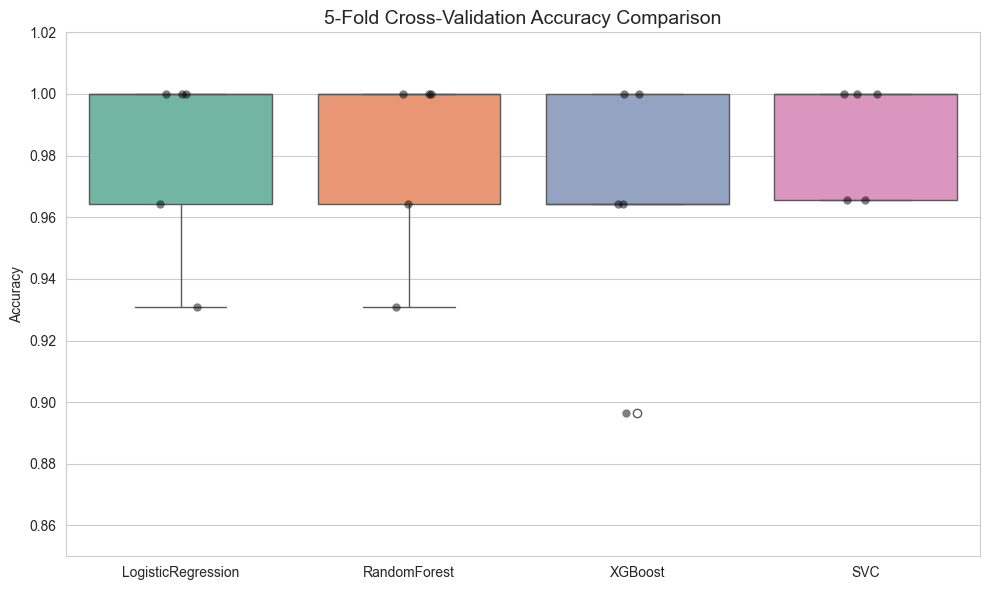


Most stable model (lowest std): SVC (std=0.0189)
Best mean CV accuracy: SVC (0.9862)


In [42]:
# Box plot of CV scores
cv_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=cv_df, ax=ax, palette="Set2")
sns.stripplot(data=cv_df, ax=ax, color="black", alpha=0.5, size=6)
ax.set_title("5-Fold Cross-Validation Accuracy Comparison", fontsize=14)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.85, 1.02)
plt.tight_layout()
plt.show()

print(f"\nMost stable model (lowest std): {cv_df.std().idxmin()} (std={cv_df.std().min():.4f})")
print(f"Best mean CV accuracy: {cv_df.mean().idxmax()} ({cv_df.mean().max():.4f})")

### Grid Search Hyperparameter Tuning

Grid Search exhaustively tries every combination of hyperparameters you specify.
It is simple and thorough, but can be slow if the parameter grid is large.
We use GridSearchCV which combines grid search with k-fold cross-validation.

#### Bias-Variance Connection

Hyperparameters are the controls for the **bias-variance tradeoff**.
Each hyperparameter shifts the balance toward one end of the spectrum:
- **`C`** (LogisticRegression/SVC): lower C = stronger regularization → higher bias,
  lower variance. Higher C = less regularization → lower bias, higher variance.
- **`max_depth`** (RF/XGBoost): deeper trees capture more detail → lower bias,
  higher variance. Shallower trees → higher bias, lower variance.
- **`n_estimators`** (RF/XGBoost): more trees average out noise → lower variance,
  no significant bias change (after a minimum threshold).

When tuning, track both train and validation scores to see which direction
your model is moving on the bias-variance axis.


In [43]:
# TODO: Define parameter grids for Random Forest and XGBoost
# Each grid is a dictionary where keys are parameter names and values are lists of options.
#
# For Random Forest:
#   n_estimators: [50, 100, 200] — more trees = more stable, slower
#   max_depth: [5, 10, None] — None means unlimited depth
#
# For XGBoost:
#   n_estimators: [50, 100] — boosting rounds
#   max_depth: [3, 5, 7] — XGBoost trees are typically shallower

# param_grids = {
#     "RandomForest": {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None]},
#     "XGBoost": {"n_estimators": [50, 100], "max_depth": [3, 5, 7]},
# }


In [44]:
# Parameter grids for Grid Search
param_grids = {
    "RandomForest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.05, 0.1, 0.2],
    },
}

print("Parameter grids defined:")
for name, grid in param_grids.items():
    combos = 1
    for v in grid.values():
        combos *= len(v)
    print(f"  {name}: {combos} combinations")

Parameter grids defined:
  RandomForest: 18 combinations
  XGBoost: 27 combinations


In [45]:
# TODO: Run GridSearchCV for Random Forest
# GridSearchCV takes a model, a parameter grid, cv, and scoring.
# Use cv=3 (3-fold CV) to keep training time manageable.
#
# grid_rf = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grids["RandomForest"],
#     cv=3, scoring="accuracy"
# )
# grid_rf.fit(X_train, y_train)
#
# print(f"Best RF params: {grid_rf.best_params_}")
# print(f"Best RF CV Accuracy: {grid_rf.best_score_:.4f}")


In [46]:
# GridSearchCV for Random Forest
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grids["RandomForest"],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True,
)
grid_rf.fit(X_train, y_train)

print(f"Best RF params: {grid_rf.best_params_}")
print(f"Best RF CV F1 Macro: {grid_rf.best_score_:.4f}")

# Test set performance
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_test)
print(f"Tuned RF Test Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned RF Test F1 Macro: {f1_score(y_test, y_pred_rf_tuned, average='macro'):.4f}")

# GridSearchCV for XGBoost
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, verbosity=0),
    param_grids["XGBoost"],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True,
)
grid_xgb.fit(X_train, y_train)

print(f"\nBest XGBoost params: {grid_xgb.best_params_}")
print(f"Best XGBoost CV F1 Macro: {grid_xgb.best_score_:.4f}")

y_pred_xgb_tuned = grid_xgb.best_estimator_.predict(X_test)
print(f"Tuned XGBoost Test Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Tuned XGBoost Test F1 Macro: {f1_score(y_test, y_pred_xgb_tuned, average='macro'):.4f}")

Best RF params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV F1 Macro: 0.9789
Tuned RF Test Accuracy: 1.0000
Tuned RF Test F1 Macro: 1.0000

Best XGBoost params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best XGBoost CV F1 Macro: 0.9661
Tuned XGBoost Test Accuracy: 0.9722
Tuned XGBoost Test F1 Macro: 0.9743


### Seed Experiments (Random State Sensitivity)

Some models (Random Forest, XGBoost) use randomness during training.
Different random seeds can produce different results. Testing multiple seeds
helps you understand whether your model is stable or sensitive to the random state.

#### Bias-Variance Connection

Seed sensitivity is a direct measure of **variance**. A model whose performance
fluctuates significantly across seeds has high variance — it is unstable and
its predictions are not reproducible in a reliable way.

- Low variance: F1 varies by <1% across seeds. The model is stable.
- High variance: F1 varies by >5% across seeds. The model needs regularization
  (reduce `max_depth`, increase `min_samples_split`, or lower `learning_rate`).

Ensemble methods (Random Forest, XGBoost) are designed to reduce variance compared
to a single decision tree, but they can still show seed sensitivity on small datasets
or when trees are allowed to grow very deep.


In [47]:
# TODO: Test how sensitive Random Forest is to the random seed
# Try seeds like [42, 123, 456, 789, 1024, 2022].
# For each seed:
#   1. Create a RandomForestClassifier(n_estimators=100, random_state=seed)
#   2. Fit on X_train, predict on X_test
#   3. Calculate accuracy and store the result
#
# After the loop, print the mean and standard deviation of the accuracy scores.
# A low standard deviation means the model is stable across different seeds.
#
# seeds = [42, 123, 456, 789, 1024, 2022]
# seed_results = []
# for seed in seeds:
#     ....


=== Seed Sensitivity (10 random seeds) ===
  RandomForest   : Mean=1.0000, Std=0.0000, Range=[1.0000, 1.0000]
  XGBoost        : Mean=1.0000, Std=0.0000, Range=[1.0000, 1.0000]


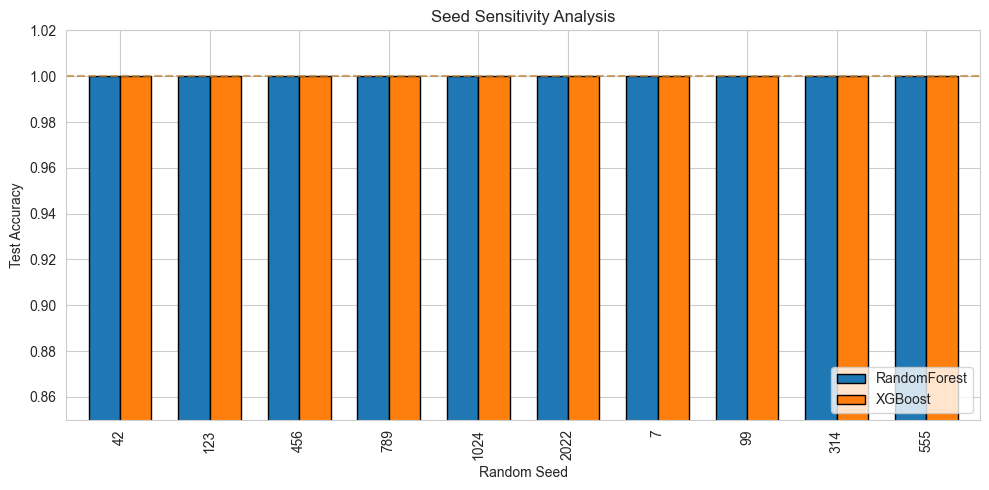


Random Forest stability: Good (<1% std)
XGBoost stability: Good (<1% std)


In [48]:
# Random Seed Sensitivity Analysis
seeds = [42, 123, 456, 789, 1024, 2022, 7, 99, 314, 555]
seed_results = {"RandomForest": [], "XGBoost": []}

for seed in seeds:
    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)
    rf.fit(X_train, y_train)
    seed_results["RandomForest"].append(accuracy_score(y_test, rf.predict(X_test)))

    # XGBoost
    xgb = XGBClassifier(n_estimators=100, random_state=seed, verbosity=0)
    xgb.fit(X_train, y_train)
    seed_results["XGBoost"].append(accuracy_score(y_test, xgb.predict(X_test)))

# Summary
print("=== Seed Sensitivity (10 random seeds) ===")
for name, scores in seed_results.items():
    scores_arr = np.array(scores)
    print(f"  {name:15s}: Mean={scores_arr.mean():.4f}, Std={scores_arr.std():.4f}, "
          f"Range=[{scores_arr.min():.4f}, {scores_arr.max():.4f}]")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
seed_df = pd.DataFrame(seed_results, index=seeds)
seed_df.plot(kind="bar", ax=ax, width=0.7, edgecolor="black")
ax.set_xlabel("Random Seed")
ax.set_ylabel("Test Accuracy")
ax.set_title("Seed Sensitivity Analysis")
ax.set_ylim(0.85, 1.02)
ax.axhline(y=seed_df["RandomForest"].mean(), color="steelblue", linestyle="--", alpha=0.5)
ax.axhline(y=seed_df["XGBoost"].mean(), color="darkorange", linestyle="--", alpha=0.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Interpretation
rf_std = np.std(seed_results["RandomForest"])
xgb_std = np.std(seed_results["XGBoost"])
print(f"\nRandom Forest stability: {'Good (<1% std)' if rf_std < 0.01 else 'Moderate'}")
print(f"XGBoost stability: {'Good (<1% std)' if xgb_std < 0.01 else 'Moderate'}")

### Optuna Hyperparameter Optimization

Optuna is a Bayesian optimization framework that is smarter than Grid Search.
Instead of trying all combinations, it uses past trial results to suggest promising
hyperparameters for the next trial. This often finds better parameters in fewer iterations.

You define an **objective function** that takes a `trial` object and uses
`trial.suggest_int()`, `trial.suggest_float()`, etc. to define the search space.
The function returns a metric, and Optuna maximizes or minimizes it.

Similarly to mlflow, Optuna runs are called `studies` and each trial is a single set of hyperparameters and its resulting metric.
The `create_study()` function initializes a new study, and `study.optimize()` runs the optimization process.
`create_study()` takes parameters:

- `direction`: "maximize" or "minimize" depending on whether you want to maximize a score (like accuracy) or minimize an error.
- `sampler`: The algorithm used to suggest hyperparameters. `TPESampler` is a common choice for Bayesian optimization.
- `pruner`: An optional component that can stop unpromising trials early to save time. `MedianPruner` is a simple choice that prunes trials that perform worse than the median of completed trials.

In [49]:
# TODO: Define the Optuna objective function for XGBoost
# Use trial.suggest_int() for integer parameters (n_estimators, max_depth)
# and trial.suggest_float() with log=True for continuous parameters (learning_rate).
#
# Inside the function, create an XGBClassifier with the suggested params,
# run 3-fold cross-validation with scoring="accuracy",
# and return the mean score. Optuna will maximize this.
# XGBoost handles multiclass natively (uses softprob objective automatically).

# def objective_xgb(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 50, 300),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#     }
#     model = XGBClassifier(**params, random_state=42)
#     scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
#     return scores.mean()


In [50]:
# Optuna objective function for XGBoost
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    model = XGBClassifier(**params, random_state=42, verbosity=0)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

print("Optuna XGBoost objective defined")

Optuna XGBoost objective defined


In [51]:
# TODO: Run Optuna optimization for XGBoost
# Create a study with direction="maximize" (we want to maximize accuracy).
# Run optimize() with n_trials=50 (or fewer if you want faster results).
# Print the best score and best parameters.
#
# study_xgb = optuna.create_study(direction="maximize")
# study_xgb.optimize(objective_xgb, n_trials=50)
# print(f"Best XGBoost CV Accuracy: {study_xgb.best_value:.4f}")
# print(f"Best XGBoost params: {study_xgb.best_params}")


In [52]:
# Run Optuna XGBoost optimization
study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=False)

print(f"Best XGBoost CV F1 Macro: {study_xgb.best_value:.4f}")
print(f"Best XGBoost params: {study_xgb.best_params}")

# Evaluate on test set
best_xgb = XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0)
best_xgb.fit(X_train, y_train)
y_pred_optuna_xgb = best_xgb.predict(X_test)
print(f"\nOptuna XGBoost Test Accuracy: {accuracy_score(y_test, y_pred_optuna_xgb):.4f}")
print(f"Optuna XGBoost Test F1 Macro: {f1_score(y_test, y_pred_optuna_xgb, average='macro'):.4f}")

Best XGBoost CV F1 Macro: 0.9789
Best XGBoost params: {'n_estimators': 95, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_alpha': 0.014618962793704957, 'reg_lambda': 0.2801635158716261}

Optuna XGBoost Test Accuracy: 1.0000
Optuna XGBoost Test F1 Macro: 1.0000


In [53]:
# TODO: Define and run Optuna optimization for Random Forest
# Random Forest has different parameters. The search space might include:
#   - n_estimators: 50 to 300
#   - max_depth: 3 to 20
#   - min_samples_split: 2 to 20
#
# Define the objective function similar to XGBoost, but for Random Forest.
# Then create a study and optimize it, printing the best results.
#
# print(f"Best RF CV Accuracy: {study_rf.best_value:.4f}")
# print(f"Best RF params: {study_rf.best_params}")


In [54]:
# Optuna objective for Random Forest
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

# Run Optuna RF optimization
study_rf = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=False)

print(f"Best RF CV F1 Macro: {study_rf.best_value:.4f}")
print(f"Best RF params: {study_rf.best_params}")

# Evaluate on test set
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
y_pred_optuna_rf = best_rf.predict(X_test)
print(f"\nOptuna RF Test Accuracy: {accuracy_score(y_test, y_pred_optuna_rf):.4f}")
print(f"Optuna RF Test F1 Macro: {f1_score(y_test, y_pred_optuna_rf, average='macro'):.4f}")

Best RF CV F1 Macro: 0.9789
Best RF params: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Optuna RF Test Accuracy: 1.0000
Optuna RF Test F1 Macro: 1.0000


### Model Comparison & Saving

After all tuning is complete, compile the results into a comparison table,
select the best overall model, and save it for later use.

#### Bias-Variance Connection

When comparing baseline vs tuned models, check for signs of overfitting:
- If test accuracy improved but **train accuracy slightly decreased**, you likely reduced
  bias at an acceptable variance cost — this is healthy tuning.
- If **train accuracy is excellent** but test accuracy is poor, you **overfit** — the model
  has high variance. Increase regularization (reduce `max_depth`,
  increase `min_samples_split`, or decrease `C` for linear models).
- If **both train and test accuracy are poor**, the model has high bias — it is too
  simple. Increase model capacity (more trees, deeper trees, lower regularization).

A well-tuned model sits at the sweet spot of the bias-variance tradeoff:
low enough bias to capture the pattern, low enough variance to generalize.

Edit the Code cells in the notebook to track your experiment results. Either run them sequentially as presented, or
create a loop to run multiple seeds or hyperparameter combinations. The key is to track everything in MLflow so you can compare later!

In [55]:
# TODO: Compile baseline and tuned results into a comparison DataFrame
# Create a table with Model names, Baseline Accuracy, and Tuned Accuracy.
# Then plot a grouped bar chart to visualize improvements from tuning.
#
# comparison = pd.DataFrame({
#     "Model": ["LogisticRegression", "RandomForest", "XGBoost", "SVC"],
#     "Baseline_Accuracy": [...],  # fill in your baseline scores
#     "Tuned_Accuracy": [...],     # fill in your tuned scores
# })
# print(comparison)
#
# comparison_melted = comparison.melt(id_vars=["Model"], var_name="Type", value_name="Accuracy")
# sns.barplot(data=comparison_melted, x="Model", y="Accuracy", hue="Type")
# plt.title("Model Performance: Baseline vs Tuned")
# plt.xticks(rotation=45)
# plt.show()


=== Baseline vs Tuned Comparison ===
                Model  Baseline_Accuracy  Tuned_Accuracy  Improvement
0  LogisticRegression             0.9722          0.9722          0.0
1        RandomForest             1.0000          1.0000          0.0
2             XGBoost             1.0000          1.0000          0.0
3                 SVC             0.9722          0.9722          0.0


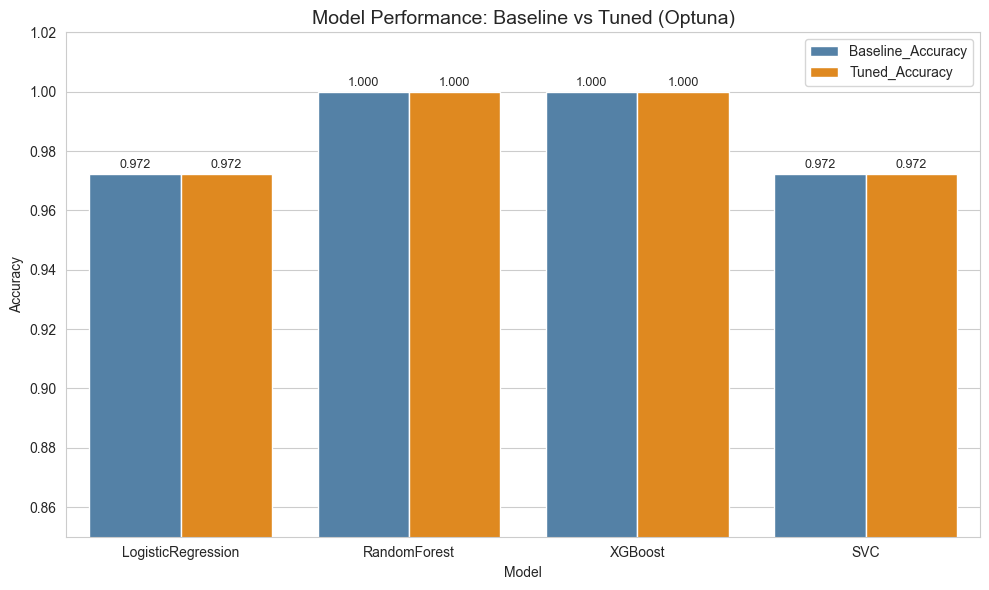


Best model: RandomForest (Tuned Accuracy: 1.0000)


In [56]:
# Compile baseline vs tuned results
# Baseline scores
lr_baseline_acc = baseline_results["LogisticRegression"]["Accuracy"]
rf_baseline_acc = baseline_results["RandomForest"]["Accuracy"]
xgb_baseline_acc = baseline_results["XGBoost"]["Accuracy"]
svc_baseline_acc = baseline_results["SVC"]["Accuracy"]

# Tuned scores (LR and SVC keep baseline — no tuning applied here)
lr_tuned_acc = lr_baseline_acc
svc_tuned_acc = svc_baseline_acc
rf_tuned_acc = accuracy_score(y_test, y_pred_optuna_rf)
xgb_tuned_acc = accuracy_score(y_test, y_pred_optuna_xgb)

comparison = pd.DataFrame({
    "Model": ["LogisticRegression", "RandomForest", "XGBoost", "SVC"],
    "Baseline_Accuracy": [lr_baseline_acc, rf_baseline_acc, xgb_baseline_acc, svc_baseline_acc],
    "Tuned_Accuracy": [lr_tuned_acc, rf_tuned_acc, xgb_tuned_acc, svc_tuned_acc],
})
comparison["Improvement"] = comparison["Tuned_Accuracy"] - comparison["Baseline_Accuracy"]
print("=== Baseline vs Tuned Comparison ===")
print(comparison.round(4))

# Grouped bar chart
comparison_melted = comparison.melt(id_vars=["Model"], value_vars=["Baseline_Accuracy", "Tuned_Accuracy"],
                                     var_name="Type", value_name="Accuracy")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=comparison_melted, x="Model", y="Accuracy", hue="Type", ax=ax, palette=["steelblue", "darkorange"])
ax.set_title("Model Performance: Baseline vs Tuned (Optuna)", fontsize=14)
ax.set_ylim(0.85, 1.02)
ax.legend(title="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)
plt.tight_layout()
plt.show()

# Best overall
best_idx = comparison["Tuned_Accuracy"].idxmax()
print(f"\nBest model: {comparison.loc[best_idx, 'Model']} (Tuned Accuracy: {comparison.loc[best_idx, 'Tuned_Accuracy']:.4f})")

In [57]:
# TODO: Train the best model on the full training set and save it
# Use the best parameters from Optuna (or GridSearch) to create the final model.
# Fit it on the full training data, then save with joblib.

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# best_params = study_xgb.best_params
# best_model = XGBClassifier(**best_params, random_state=42)
# best_model.fit(X_train, y_train)
# joblib.dump(best_model, MODELS_DIR / "best_tuned_model.pkl")
# print("Best model saved to models/best_tuned_model.pkl")
#
# TODO: Verify the saved model loads and produces consistent predictions
# loaded = joblib.load(MODELS_DIR / "best_tuned_model.pkl")
# y_pred = loaded.predict(X_test)
# print(f"Final model Accuracy: {accuracy_score(y_test, y_pred):.4f}")


In [58]:
# Train the best model on full training data and save
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Determine best model
best_model_name = comparison.loc[comparison["Tuned_Accuracy"].idxmax(), "Model"]
print(f"Best model: {best_model_name}")

if best_model_name == "XGBoost":
    best_model = XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0)
    best_model.fit(X_train, y_train)
elif best_model_name == "RandomForest":
    best_model = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
    best_model.fit(X_train, y_train)
elif best_model_name == "SVC":
    best_model = SVC(kernel="rbf", random_state=42)
    best_model.fit(X_train_scaled, y_train)
else:
    best_model = LogisticRegression(max_iter=5000, random_state=42, solver="lbfgs")
    best_model.fit(X_train_scaled, y_train)

# Save model
joblib.dump(best_model, MODELS_DIR / "best_tuned_model.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
print(f"Model saved to: {MODELS_DIR / 'best_tuned_model.pkl'}")
print(f"Scaler saved to: {MODELS_DIR / 'scaler.pkl'}")

# Verify saved model
loaded_model = joblib.load(MODELS_DIR / "best_tuned_model.pkl")
X_verify = X_test_scaled if best_model_name in ["LogisticRegression", "SVC"] else X_test
y_pred_verify = loaded_model.predict(X_verify)
print(f"\nVerification — Loaded model Accuracy: {accuracy_score(y_test, y_pred_verify):.4f}")
print(f"Verification — Loaded model F1 Macro: {f1_score(y_test, y_pred_verify, average='macro'):.4f}")

Best model: RandomForest
Model saved to: ..\models\best_tuned_model.pkl
Scaler saved to: ..\models\scaler.pkl

Verification — Loaded model Accuracy: 1.0000
Verification — Loaded model F1 Macro: 1.0000
